In [406]:
import pandas as pd 
import numpy as np 
import pickle

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MultiLabelBinarizer


%matplotlib inline

In [408]:
df = pd.read_csv("data/tmdb_5000_movies.csv")
df_titles = pd.read_csv("data/titles.csv")
df_metadata = pd.read_csv("data/movie_metadata.csv")

In [410]:
df_titles.head()

,title
0,Avatar
1,Pirates of the Caribbean: At World's End
2,Spectre
3,The Dark Knight Rises
4,John Carter


In [412]:
df.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [414]:
df['original_language'].unique()

array(['en', 'ja', 'fr', 'zh', 'es', 'de', 'hi', 'ru', 'ko', 'te', 'cn',
       'it', 'nl', 'ta', 'sv', 'th', 'da', 'xx', 'hu', 'cs', 'pt', 'is',
       'tr', 'nb', 'af', 'pl', 'he', 'ar', 'vi', 'ky', 'id', 'ro', 'fa',
       'no', 'sl', 'ps', 'el'], dtype=object)

In [416]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [418]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [420]:
print(f"Percentage of null values in each column: {(df.isnull().sum()/df.shape[0])*100}")

Percentage of null values in each column: budget                   0.000000
genres                   0.000000
homepage                64.355611
id                       0.000000
keywords                 0.000000
original_language        0.000000
original_title           0.000000
overview                 0.062461
popularity               0.000000
production_companies     0.000000
production_countries     0.000000
release_date             0.020820
revenue                  0.000000
runtime                  0.041641
spoken_languages         0.000000
status                   0.000000
tagline                 17.572351
title                    0.000000
vote_average             0.000000
vote_count               0.000000
dtype: float64


In [422]:
df.drop(['homepage','tagline'], inplace=True, axis=1)
df.dropna(inplace=True)

In [424]:
df.isnull().sum().sum()

0

In [426]:
df.genres[0]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [428]:
def clean_columns(col_series):
    def extract_names(name_json):
        try:
            names_list = json.loads(name_json)
            return ', '.join(name['name'] for name in names_list)
        except (json.JSONDecodeError, TypeError):
            return ''
    
    return col_series.apply(extract_names)

In [430]:
df.genres = clean_columns(df.genres)
df.keywords = clean_columns(df.keywords)
df.production_companies = clean_columns(df.production_companies)
df.production_countries = clean_columns(df.production_countries)
df.spoken_languages = clean_columns(df.spoken_languages)

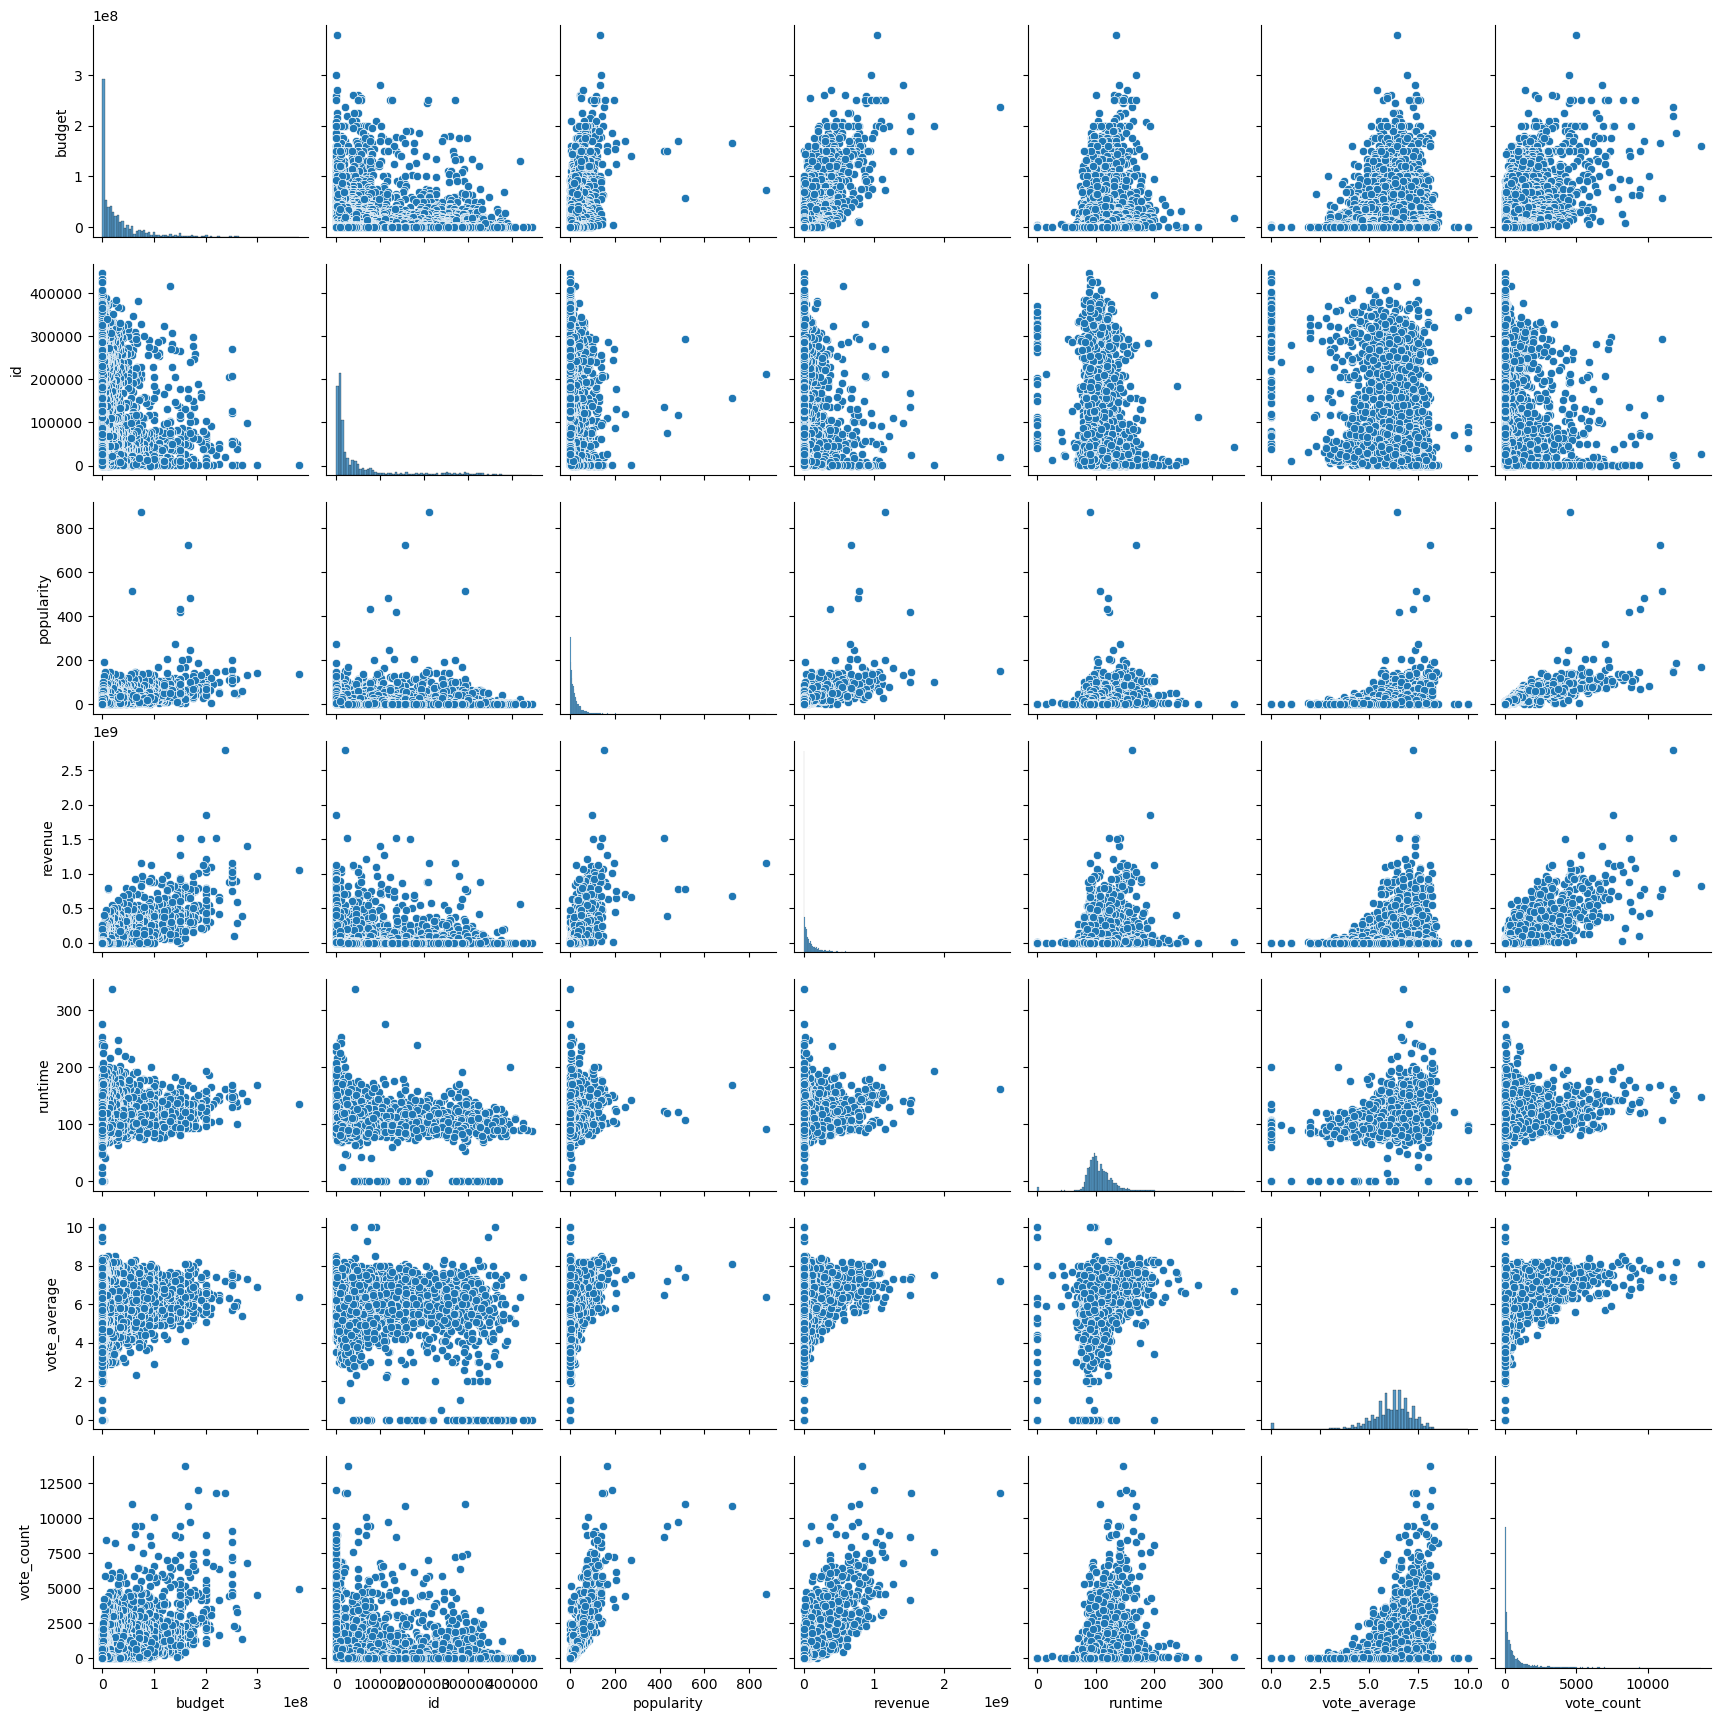

In [386]:
sns.pairplot(df)
plt.show()

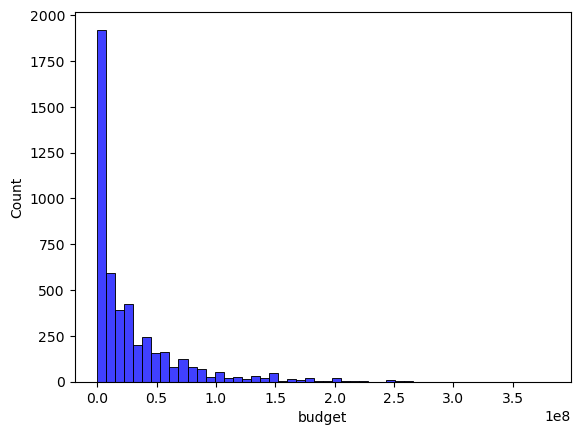

In [58]:
sns.histplot(df.budget,bins=50,color='blue')
plt.show()

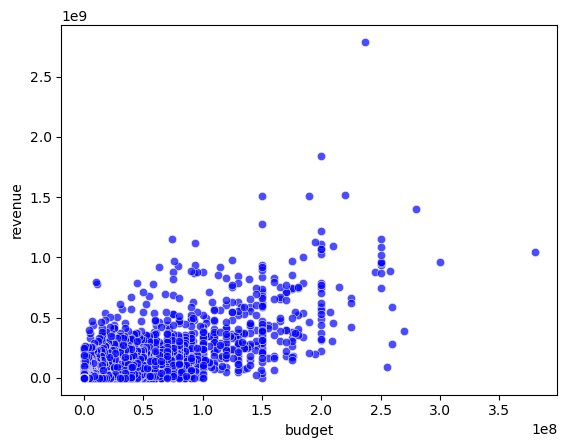

In [59]:
sns.scatterplot(x=df['budget'],y=df['revenue'],alpha=0.7,color='blue')
plt.savefig('budget_revenue_scatter')
plt.show()

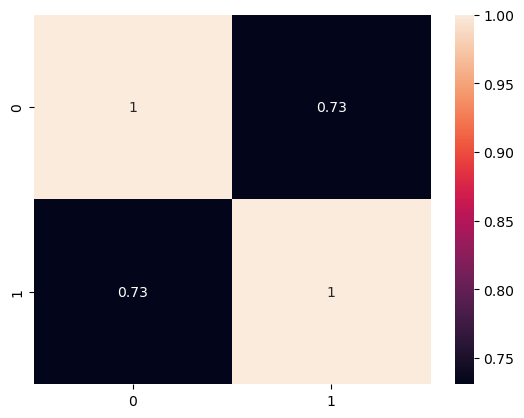

In [60]:
a = np.corrcoef(df['budget'],df['revenue'])
sns.heatmap(a,annot=True)
plt.show()

In [69]:
df.genres

0       Action, Adventure, Fantasy, Science Fiction
1                        Adventure, Fantasy, Action
2                          Action, Adventure, Crime
3                    Action, Crime, Drama, Thriller
4                Action, Adventure, Science Fiction
                           ...                     
4798                        Action, Crime, Thriller
4799                                Comedy, Romance
4800               Comedy, Drama, Romance, TV Movie
4801                                               
4802                                    Documentary
Name: genres, Length: 4799, dtype: object

In [432]:
def extract_main_and_create_dummies(df, column_names):
    for col in column_names:
        main_col = f"main_{col}"
        
        df[main_col] = df[col].apply(
            lambda x: next((g.strip() for g in x.split(',') if g.strip() and g.strip().lower() != 'nan'), None)
            if isinstance(x, str) else None
        )

        dummies = pd.get_dummies(df[main_col], prefix=f'{col}')
        
        df = df.join(dummies)

    return df

df = extract_main_and_create_dummies(df, ['genres'])

In [437]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

cols_to_drop = [
    'genres', 'id', 'keywords', 'original_language', 'original_title',
    'overview', 'popularity', 'production_companies', 'production_countries',
    'release_date', 'spoken_languages', 'status', 
    'vote_count', 'vote_average' ,'main_genres','runtime']

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

X = df.drop(columns=['title'])  
y = df['title']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)


knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', NearestNeighbors(n_neighbors=10, metric='cosine'))  
])

knn_pipeline.fit(X_train)


with open('knn_movie_recommendation_model.pkl', 'wb') as f:
    pickle.dump({
        'model': knn_pipeline.named_steps['knn'],
        'scaler': knn_pipeline.named_steps['preprocessor'],
        'df_index': df.index.tolist()  
    }, f)


In [445]:
import pickle

with open('knn_movie_recommendation_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print(loaded_model.keys())  

knn_model = loaded_model['model']


movie_index = 4

distances, indices = knn_model.kneighbors(X_test.iloc[movie_index].values.reshape(1, -1))

print(f"Top 10 similar movies to '{y_test.iloc[movie_index]}':")
for i, idx in enumerate(indices[0]):
    movie_idx_in_train_set = X_train.index[idx]
    print(f"{i+1}. {y[movie_idx_in_train_set]} (Distance: {distances[0][i]:.4f})")


dict_keys(['model', 'scaler', 'df_index'])
Top 10 similar movies to 'Django Unchained':
1. Avatar (Distance: 0.0039)
2. Jurassic World (Distance: 0.0102)
3. The Lord of the Rings: The Return of the King (Distance: 0.0112)
4. Minions (Distance: 0.0127)
5. Titanic (Distance: 0.0133)
6. The Secret Life of Pets (Distance: 0.0188)
7. Jurassic Park (Distance: 0.0197)
8. Frozen (Distance: 0.0197)
9. Ice Age: Dawn of the Dinosaurs (Distance: 0.0198)
10. The Lord of the Rings: The Fellowship of the Ring (Distance: 0.0216)
